In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import scipy
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("SciPy:", scipy.__version__)

# Notebookをどこから開いても，同じ作業フォルダとデータフォルダを参照する．
# PROJECT_DIR = Path.home() / "applied_programming_ii" / "02"
# DATA_DIR = Path.home() / "applied_programming_ii" / "data"
# FIGURE_DIR = PROJECT_DIR / "reports" / "figures"
PROJECT_DIR = Path(".")
DATA_DIR = Path("../../data")
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("作業フォルダ:", PROJECT_DIR)
print("データフォルダ:", DATA_DIR)
print("人口データの有無:", (DATA_DIR / "population_japan.csv").exists())

NumPy: 2.0.2
pandas: 2.3.3
SciPy: 1.13.1
作業フォルダ: .
データフォルダ: ../../data
人口データの有無: True


In [2]:
# 解析解を基準として数値解の誤差を評価する．
def exponential_solution(t, x0, r, t0=0.0):
    """dx/dt = r x, x(t0) = x0 の解析解 x0 * exp(r (t - t0)) を返す．"""
    return x0 * np.exp(r * (t - t0))


# 手計算で確かめた値と照合する．h = 1 で3ステップ進めると x(3) = 172.8 であった．
print("解析解 x(3) =", round(float(exponential_solution(3.0, 100.0, 0.2)), 2))
print("解析解 x(2) =", round(float(exponential_solution(2.0, 100.0, 0.2)), 2))

解析解 x(3) = 182.21
解析解 x(2) = 149.18


In [3]:
def euler(rhs, t_span, x0, h, args=()):
    """前進Euler法で初期値問題 x' = rhs(t, x, *args), x(t0) = x0 を解く．

    rhs: 右辺の関数．rhs(t, x, *args) の形で呼び出す．
    t_span: (t0, t_end) 計算区間．
    x0: 初期値．
    h: 刻み幅．
    args: rhs に渡すパラメタのタプル．
    戻り値: 時刻の配列 t と近似解の配列 x．
    """
    t0, t_end = t_span
    n_steps = int(round((t_end - t0) / h))
    t = t0 + h * np.arange(n_steps + 1)
    x = np.zeros(n_steps + 1)
    x[0] = x0
    for k in range(n_steps):
        x[k + 1] = x[k] + h * rhs(t[k], x[k], *args)
    return t, x


# 右辺の関数は solve_ivp と同じ rhs(t, x, パラメタ...) の形で書く．
def exponential_rhs(t, x, r):
    """dx/dt = r x の右辺．"""
    return r * x


# 手計算（h = 1 で3ステップ）と実装が一致することを確認する．
t_check, x_check = euler(exponential_rhs, (0.0, 3.0), 100.0, 1.0, args=(0.2,))
print("t =", t_check)
print("x =", x_check)

t = [0. 1. 2. 3.]
x = [100.  120.  144.  172.8]


In [19]:
# パラメタ
r = 0.2          # 増加率 [1/日]

# 初期条件と計算区間
x0 = 100.0       # 初期値 [g]
t_span = (0.0, 10.0)   # 0日から10日まで

# 刻み幅を変えて計算する
h_values = [1.0, 0.5, 0.1, 0.01]

print(f"{'h':>6} {'ステップ数':>8} {'x(10)の数値解':>14} {'解析解':>10} {'誤差':>10}")
for h in h_values:
    t, x = euler(exponential_rhs, t_span, x0, h, args=(r,))
    exact_end = exponential_solution(t[-1], x0, r)
    error = x[-1] - exact_end
    print(f"{h:6.2f} {len(t) - 1:8d} {x[-1]:14.2f} {exact_end:10.2f} {error:10.2f}")

     h    ステップ数      x(10)の数値解        解析解         誤差
  1.00       10         619.17     738.91    -119.73
  0.50       20         672.75     738.91     -66.16
  0.10      100         724.46     738.91     -14.44
  0.01     1000         737.43     738.91      -1.47


In [20]:
# 演習2：刻み幅を大きくした場合と小さくした場合を追加して確認する．
for h in [5.0, 2.0, 1.0, 0.1, 0.01, 0.001]:
    t, x = euler(exponential_rhs, t_span, x0, h, args=(r,))
    exact_end = exponential_solution(t[-1], x0, r)
    error = x[-1] - exact_end
    print(f"h = {h:6.3f}  ステップ数 = {len(t) - 1:6d}  x(10) = {x[-1]:9.2f}  誤差 = {error:9.2f}")

h =  5.000  ステップ数 =      2  x(10) =    400.00  誤差 =   -338.91
h =  2.000  ステップ数 =      5  x(10) =    537.82  誤差 =   -201.08
h =  1.000  ステップ数 =     10  x(10) =    619.17  誤差 =   -119.73
h =  0.100  ステップ数 =    100  x(10) =    724.46  誤差 =    -14.44
h =  0.010  ステップ数 =   1000  x(10) =    737.43  誤差 =     -1.47
h =  0.001  ステップ数 =  10000  x(10) =    738.76  誤差 =     -0.15


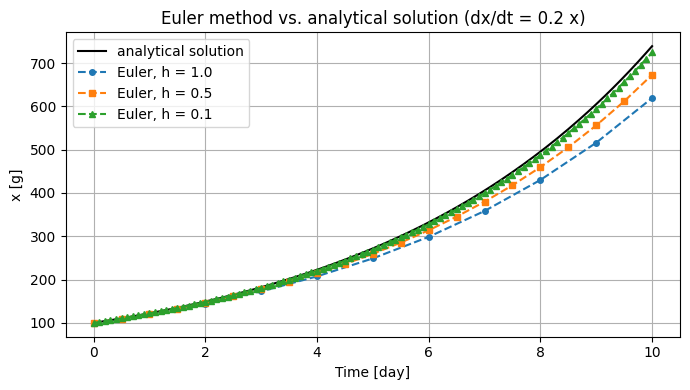

In [6]:
t_fine = np.linspace(t_span[0], t_span[1], 201)
x_exact = exponential_solution(t_fine, x0, r)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_fine, x_exact, color="black", label="analytical solution")
for h, marker in zip([1.0, 0.5, 0.1], ["o", "s", "^"]):
    t, x = euler(exponential_rhs, t_span, x0, h, args=(r,))
    ax.plot(t, x, marker=marker, markersize=4, linestyle="--", label=f"Euler, h = {h}")
ax.set_title("Euler method vs. analytical solution (dx/dt = 0.2 x)")
ax.set_xlabel("Time [day]")
ax.set_ylabel("x [g]")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "euler_vs_exact.png", dpi=150)
plt.show()

In [7]:
# 数値解を出力したい時刻
t_eval = np.linspace(t_span[0], t_span[1], 101)

sol = solve_ivp(exponential_rhs, t_span, [x0], t_eval=t_eval, args=(r,))

print("成功したか:", sol.success)
print("時刻の配列の形:", sol.t.shape)
print("解の配列の形:", sol.y.shape)
print("右辺を評価した回数:", sol.nfev)

成功したか: True
時刻の配列の形: (101,)
解の配列の形: (1, 101)
右辺を評価した回数: 26


In [8]:
x_ivp = sol.y[0]
x_exact_eval = exponential_solution(sol.t, x0, r)

print(f"solve_ivp の x(10) = {x_ivp[-1]:.4f}")
print(f"解析解の x(10)     = {x_exact_eval[-1]:.4f}")
print(f"誤差               = {x_ivp[-1] - x_exact_eval[-1]:.4f}")
print(f"最大誤差（全時刻） = {np.max(np.abs(x_ivp - x_exact_eval)):.4f}")

t_euler, x_euler = euler(exponential_rhs, t_span, x0, 0.01, args=(r,))
print(f"Euler法 h=0.01 の x(10) = {x_euler[-1]:.4f}，ステップ数 = {len(t_euler) - 1}")

solve_ivp の x(10) = 738.9245
解析解の x(10)     = 738.9056
誤差               = 0.0189
最大誤差（全時刻） = 0.0243
Euler法 h=0.01 の x(10) = 737.4312，ステップ数 = 1000


数値解から読んだ半減期: 2.40 時間
解析解の半減期 ln2/k:  2.31 時間


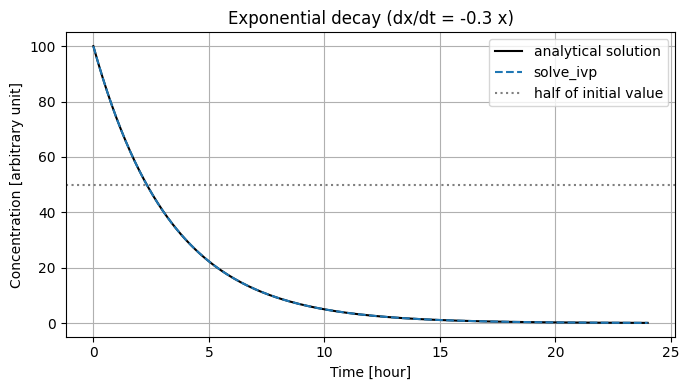

In [9]:
def decay_rhs(t, x, k):
    """dx/dt = -k x の右辺．"""
    return -k * x


k = 0.3                      # 減衰率 [1/時間]
x0_decay = 100.0             # 初期濃度 [任意単位]
t_span_decay = (0.0, 24.0)   # 0〜24時間
t_eval_decay = np.linspace(0.0, 24.0, 241)

sol_decay = solve_ivp(decay_rhs, t_span_decay, [x0_decay], t_eval=t_eval_decay, args=(k,))
x_decay = sol_decay.y[0]
x_decay_exact = x0_decay * np.exp(-k * sol_decay.t)

# 半減期：数値解が初期値の半分を下回る最初の時刻
idx_half = np.argmax(x_decay <= 0.5 * x0_decay)
print(f"数値解から読んだ半減期: {sol_decay.t[idx_half]:.2f} 時間")
print(f"解析解の半減期 ln2/k:  {np.log(2) / k:.2f} 時間")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sol_decay.t, x_decay_exact, color="black", label="analytical solution")
ax.plot(sol_decay.t, x_decay, linestyle="--", label="solve_ivp")
ax.axhline(0.5 * x0_decay, color="gray", linestyle=":", label="half of initial value")
ax.set_title("Exponential decay (dx/dt = -0.3 x)")
ax.set_xlabel("Time [hour]")
ax.set_ylabel("Concentration [arbitrary unit]")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "decay_solve_ivp.png", dpi=150)
plt.show()

In [10]:
# 演習3-4：減衰率 k を変えたときの半減期を比べる．
for k_value in [0.1, 0.3, 0.6]:
    sol_k = solve_ivp(decay_rhs, t_span_decay, [x0_decay], t_eval=t_eval_decay, args=(k_value,))
    idx = np.argmax(sol_k.y[0] <= 0.5 * x0_decay)
    print(f"k = {k_value:.1f} /時間  数値解の半減期 = {sol_k.t[idx]:5.2f} 時間  ln2/k = {np.log(2) / k_value:5.2f} 時間")

k = 0.1 /時間  数値解の半減期 =  7.00 時間  ln2/k =  6.93 時間
k = 0.3 /時間  数値解の半減期 =  2.40 時間  ln2/k =  2.31 時間
k = 0.6 /時間  数値解の半減期 =  1.20 時間  ln2/k =  1.16 時間


In [11]:
population = pd.read_csv(DATA_DIR / "population_japan.csv")
population["population_10k"] = population["total_population_thousand"] / 10

year0 = 1920
n_1920 = float(population.loc[population["year"] == 1920, "population_10k"].iloc[0])
n_1970 = float(population.loc[population["year"] == 1970, "population_10k"].iloc[0])
r_pop = np.log(n_1970 / n_1920) / (1970 - 1920)
print(f"r = {r_pop:.5f} /年")

t_eval_pop = np.arange(0, 101)          # 1920年から2020年まで [年]
sol_pop = solve_ivp(exponential_rhs, (0, 100), [n_1920], t_eval=t_eval_pop, args=(r_pop,))
n_model = sol_pop.y[0]
n_exact = exponential_solution(sol_pop.t, n_1920, r_pop)

print(f"数値解と解析解の最大差: {np.max(np.abs(n_model - n_exact)):.3f} 万人")

r = 0.01234 /年
数値解と解析解の最大差: 0.588 万人


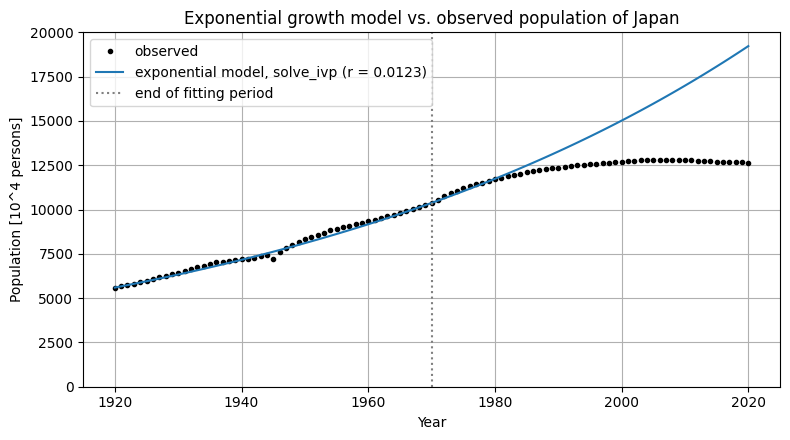

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(population["year"], population["population_10k"], color="black", marker="o", markersize=3, linestyle="none", label="observed")
ax.plot(year0 + sol_pop.t, n_model, label=f"exponential model, solve_ivp (r = {r_pop:.4f})")
ax.axvline(1970, color="gray", linestyle=":", label="end of fitting period")
ax.set_title("Exponential growth model vs. observed population of Japan")
ax.set_xlabel("Year")
ax.set_ylabel("Population [10^4 persons]")
ax.set_ylim(0, 20000)
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "population_exponential_solve_ivp.png", dpi=150)
plt.show()

In [13]:
# 演習4：数値解法の誤差（刻み幅で減らせる）と，モデルの仮定による誤差（減らせない）を区別する．
n_2020_observed = float(population.loc[population["year"] == 2020, "population_10k"].iloc[0])
n_2020_exact = float(exponential_solution(100.0, n_1920, r_pop))

for h in [10.0, 1.0]:
    t_e, n_e = euler(exponential_rhs, (0.0, 100.0), n_1920, h, args=(r_pop,))
    print(f"h = {h:5.1f} 年  Euler法の N(2020) = {n_e[-1]:10.1f} 万人"
          f"  解析解との差 = {n_e[-1] - n_2020_exact:9.1f} 万人"
          f"  観測値との差 = {n_e[-1] - n_2020_observed:9.1f} 万人")

print(f"\n解析解の N(2020) = {n_2020_exact:.1f} 万人，観測値 = {n_2020_observed:.1f} 万人")
print(f"解析解と観測値の差 = {n_2020_exact - n_2020_observed:.1f} 万人（刻み幅を変えても減らない）")

h =  10.0 年  Euler法の N(2020) =    17916.3 万人  解析解との差 =   -1306.8 万人  観測値との差 =    5301.7 万人
h =   1.0 年  Euler法の N(2020) =    19078.5 万人  解析解との差 =    -144.6 万人  観測値との差 =    6463.9 万人

解析解の N(2020) = 19223.1 万人，観測値 = 12614.6 万人
解析解と観測値の差 = 6608.5 万人（刻み幅を変えても減らない）


In [14]:
import math

print(f"倍精度の計算機イプシロン: {np.finfo(float).eps:.3e}")

# 丸め誤差：10進数の0.1は2進数では有限桁で表せない
print("0.1 + 0.2 =", 0.1 + 0.2, " 0.3と等しいか:", 0.1 + 0.2 == 0.3)

# 桁落ち：値の近い2数を引くと有効桁数が減る
print("(1 + 1e-12) - 1 =", (1.0 + 1e-12) - 1.0, " 真値 1e-12")

# 情報落ち：絶対値の大きく異なる2数を足すと小さい方が消える
print("1e16 + 1.0 - 1e16 =", 1e16 + 1.0 - 1e16, " 真値 1.0")

# 加える順序で結果が変わる：0.1を100万回足す
terms = np.full(1_000_000, 0.1)
print("単純な総和:", sum(terms), " math.fsum:", math.fsum(terms), " 真値 100000.0")

# オーバーフロー：表せる最大値を超えると inf になる
print("表せる最大値:", np.finfo(float).max)
print("1e308 * 10 =", 1e308 * 10)

倍精度の計算機イプシロン: 2.220e-16
0.1 + 0.2 = 0.30000000000000004  0.3と等しいか: False
(1 + 1e-12) - 1 = 1.000088900582341e-12  真値 1e-12
1e16 + 1.0 - 1e16 = 0.0  真値 1.0
単純な総和: 100000.00000133288  math.fsum: 100000.0  真値 100000.0
表せる最大値: 1.7976931348623157e+308
1e308 * 10 = inf


In [15]:
# 刻み幅を小さくすれば精度が上がるとは限らない．
# e^t の t = 0 における微分係数（真値は1）を差分商で近似する．
print(f"{'h':>8} {'近似値':>16} {'絶対誤差':>12}")
for h in [1e-1, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-16]:
    derivative = (np.exp(0.0 + h) - np.exp(0.0)) / h
    print(f"{h:8.0e} {derivative:16.12f} {abs(derivative - 1.0):12.3e}")

       h              近似値         絶対誤差
   1e-01   1.051709180756    5.171e-02
   1e-02   1.005016708417    5.017e-03
   1e-04   1.000050001667    5.000e-05
   1e-06   1.000000499962    5.000e-07
   1e-08   0.999999993923    6.077e-09
   1e-10   1.000000082740    8.274e-08
   1e-12   1.000088900582    8.890e-05
   1e-14   0.999200722163    7.993e-04
   1e-16   0.000000000000    1.000e+00


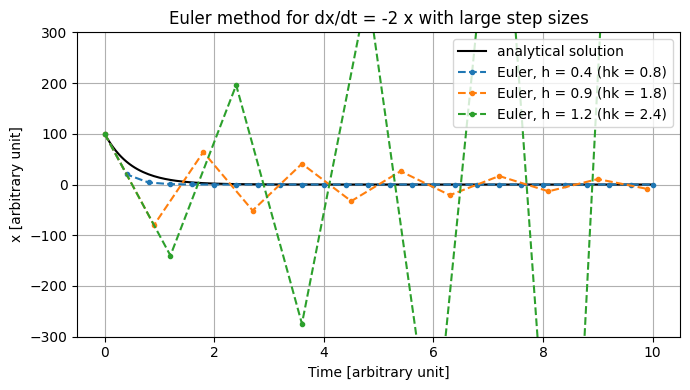

In [16]:
k = 2.0
x0_decay = 100.0
t_span_decay = (0.0, 10.0)

fig, ax = plt.subplots(figsize=(7, 4))
t_fine = np.linspace(0.0, 10.0, 201)
ax.plot(t_fine, x0_decay * np.exp(-k * t_fine), color="black", label="analytical solution")
for h in [0.4, 0.9, 1.2]:
    t, x = euler(decay_rhs, t_span_decay, x0_decay, h, args=(k,))
    ax.plot(t, x, marker="o", markersize=3, linestyle="--", label=f"Euler, h = {h} (hk = {h * k:.1f})")
ax.set_title("Euler method for dx/dt = -2 x with large step sizes")
ax.set_xlabel("Time [arbitrary unit]")
ax.set_ylabel("x [arbitrary unit]")
ax.set_ylim(-300, 300)
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "euler_instability.png", dpi=150)
plt.show()

In [17]:
# 発展演習2：同じ問題を solve_ivp で解き，解析解との絶対誤差を評価する．
t_eval_stiff = np.linspace(0.0, 10.0, 201)
sol_stiff = solve_ivp(decay_rhs, (0.0, 10.0), [x0_decay], t_eval=t_eval_stiff, args=(k,))
x_stiff_exact = x0_decay * np.exp(-k * sol_stiff.t)

print("成功したか:", sol_stiff.success)
print(f"右辺を評価した回数: {sol_stiff.nfev}")
print(f"最大絶対誤差: {np.max(np.abs(sol_stiff.y[0] - x_stiff_exact)):.6f}")

成功したか: True
右辺を評価した回数: 128
最大絶対誤差: 0.041268


In [18]:
exponential_solution(t=3.0, x0=100.0, r=0.2)

np.float64(182.21188003905093)